# ECE3403* – Data Analytics & Optimization: Project

# Team Info:
- 242000689	Mohamed Samy
- 231002196	saray youssef
- 231011495	jana emad
- 221001648	mohamed walid

## PR 2021 Competition – Product Market Type Classification
###### https://www.kaggle.com/competitions/pr-21-competition-classification/
**Goal:** Predict the Market Type (0–3) for products based on outlet and product features.

1. Data Loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing – Training Set
4. Preprocessing – Test Set
5. Modelling & Evaluation
6. Prediction & Submission

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
import warnings
warnings.simplefilter("ignore")

In [2]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

##  Data Loading

In [3]:
df = pd.read_csv("train.csv")
df.head(5)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,0
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,2
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,0
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,1
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,0


In [4]:
df_test = pd.read_csv("test.csv")
df_test.head(3)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,FDW58,20.75,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1
1,FDW14,8.30,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2
2,NCN55,14.60,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3


##  Exploratory Data Analysis

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      8523 non-null   object 
 1   X2      7060 non-null   float64
 2   X3      8523 non-null   object 
 3   X4      8523 non-null   float64
 4   X5      8523 non-null   object 
 5   X6      8523 non-null   float64
 6   X7      8523 non-null   object 
 7   X8      8523 non-null   int64  
 8   X9      6113 non-null   object 
 9   X10     8523 non-null   object 
 10  Y       8523 non-null   int64  
dtypes: float64(3), int64(2), object(6)
memory usage: 732.6+ KB


In [6]:
df.describe()

,X2,X4,X6,X8,Y
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,0.673941
std,4.643456,0.051598,62.275067,8.371760,1.046831
min,4.555000,0.000000,31.290000,1985.000000,0.000000
25%,8.773750,0.026989,93.826500,1987.000000,0.000000
50%,12.600000,0.053931,143.012800,1999.000000,0.000000
75%,16.850000,0.094585,185.643700,2004.000000,1.000000
max,21.350000,0.328391,266.888400,2009.000000,3.000000


In [7]:
df.copy1 = df.copy()  # Making a copy of the original DataFrame in case we need to revert back to it later.

In [8]:
# Dropping the 'X1' column as it is not needed for our analysis.
df.drop(columns=['X1'], inplace=True)
df.head(3)

,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,0
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,0


In [9]:
df.drop_duplicates(inplace=True)

#### Missing Values

In [10]:
print("Missing values before handling:")
df.isnull().sum()

Missing values before handling:


X2     1463
X3        0
X4        0
X5        0
X6        0
X7        0
X8        0
X9     2410
X10       0
Y         0
dtype: int64

In [11]:
# Fill missing values in X2 and X9
df['X2'].fillna(df['X2'].mean(), inplace=True)
df['X9'].fillna(df['X9'].mode()[0], inplace=True)

In [12]:
print("Missing values after handling:")
df.isnull().sum()

Missing values after handling:


X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
Y      0
dtype: int64

In [13]:
numerical_df = df.select_dtypes(include = "number")
numerical_df.head(3)

,X2,X4,X6,X8,Y
0,9.30,0.016047,249.8092,1999,0
1,5.92,0.019278,48.2692,2009,2
2,17.50,0.016760,141.6180,1999,0


In [14]:
df['X10'].value_counts()

X10
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

In [15]:
df['X10'] = df['X10'].str[-1:]

In [16]:
df.head(3)

,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,1,0
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,3,2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,1,0


### Numeric Feature Distributions

In [17]:
numerical_df = df.select_dtypes(include = "number")
numerical_df.head(2)

,X2,X4,X6,X8,Y
0,9.30,0.016047,249.8092,1999,0
1,5.92,0.019278,48.2692,2009,2


"#note: the semicolon is unneccessary but it's used to suppress the output of the last line."

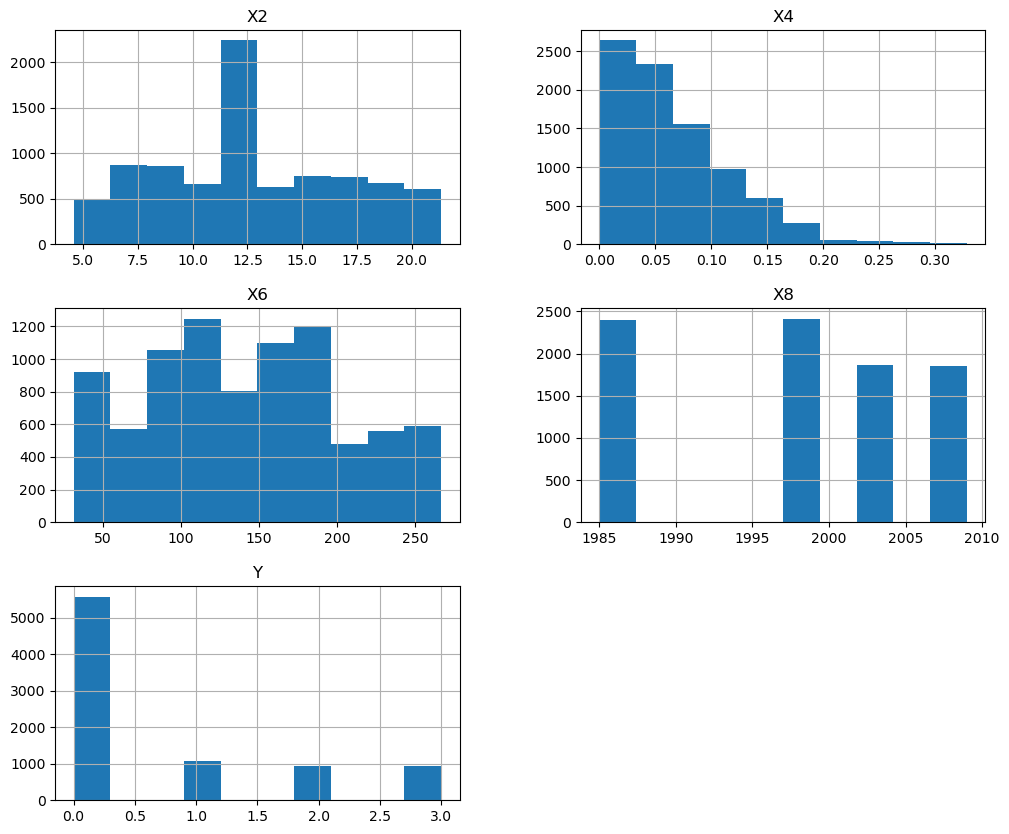

In [18]:
numerical_df.hist(figsize=(12, 10))
; #note: the semicolon is unneccessary but it's used to suppress the output of the last line.

<Axes: xlabel='X8'>

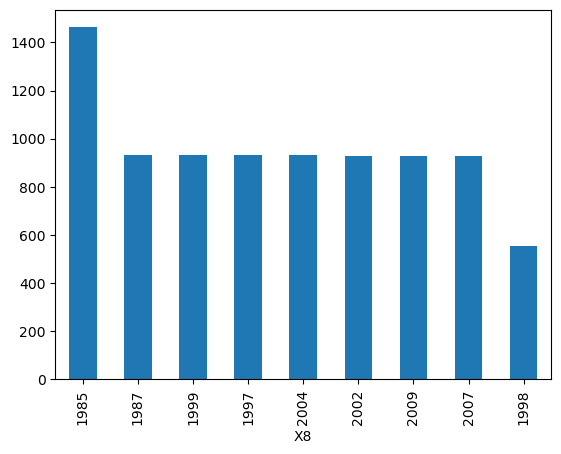

In [19]:
# Bar chart of Outlet Establishment Year — shows which years have the most outlets
df.X8.value_counts().plot(kind="bar")

Using boxplots to reveal outliers in each numeric feature


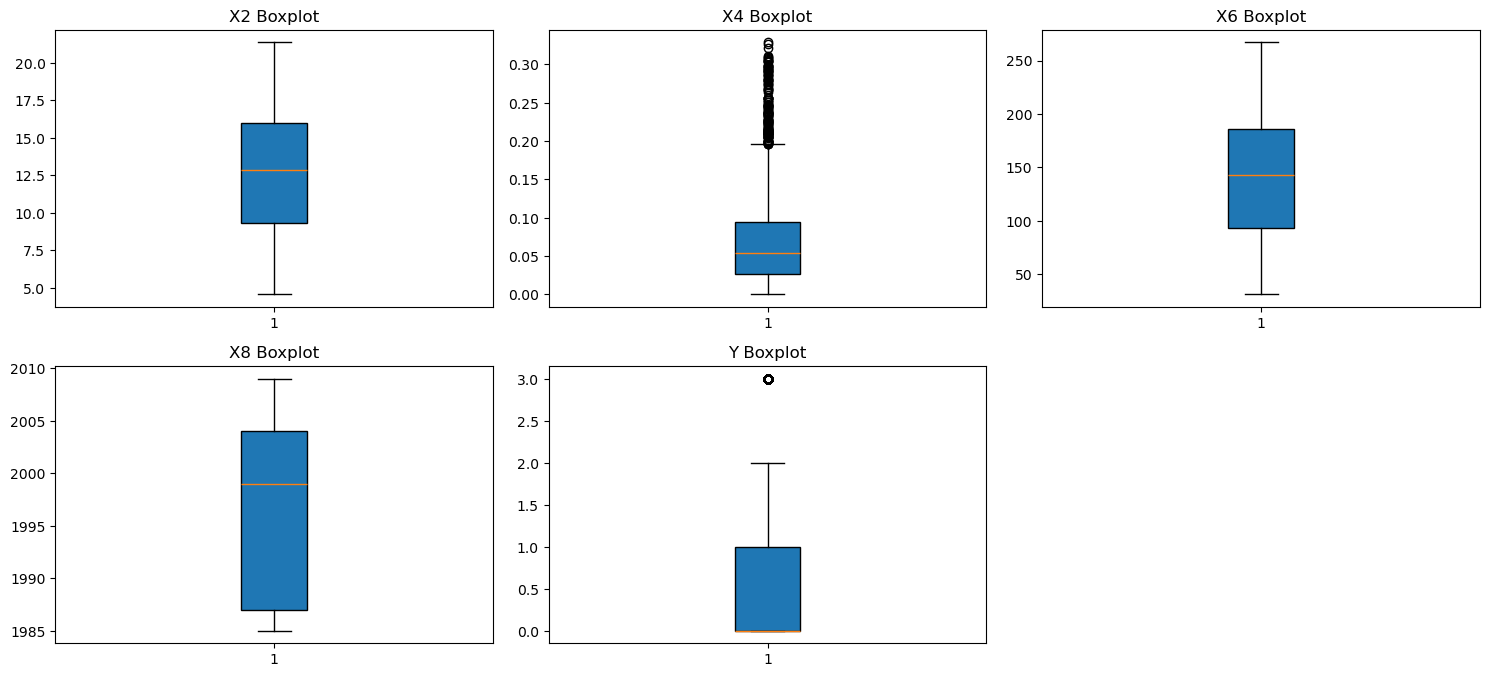

In [20]:
plt.figure(figsize=(15,10))
t=0
for i in (numerical_df.columns.tolist()):
    plt.subplot(3,3,t+1)
    plt.boxplot(df[i].dropna(), patch_artist= True)
    plt.title(f'{i} Boxplot')
    t+=1
    
plt.tight_layout()
plt.show()

Bar chart of class distribution

''

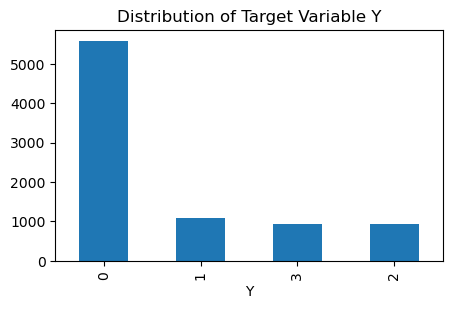

In [21]:
df.Y.value_counts().plot(kind="bar", figsize=(5, 3))
plt.title("Distribution of Target Variable Y")
;

In [22]:
# 3. Check class balance
print("Class distribution:")
print(df['Y'].value_counts())
print("Class proportions:")
print(df['Y'].value_counts(normalize=True))

Class distribution:
Y
0    5577
1    1083
3     935
2     928
Name: count, dtype: int64
Class proportions:
Y
0    0.654347
1    0.127068
3    0.109703
2    0.108882
Name: proportion, dtype: float64


#### - class 0 is heavily dominant (class imbalance)

In [23]:
# Skewness of each numeric feature
# High absolute skew (greater than 1) indicates a feature may need transformation
print(f"Skewness: \n{numerical_df.skew()}")

Skewness: 
X2    0.090561
X4    1.167091
X6    0.127202
X8   -0.396641
Y     1.254512
dtype: float64


- x4 is right skewed

In [24]:
df.head(2)

,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,1,0
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,3,2


- only X4 needs outliers handling

Visualize X4 before treatment:

''

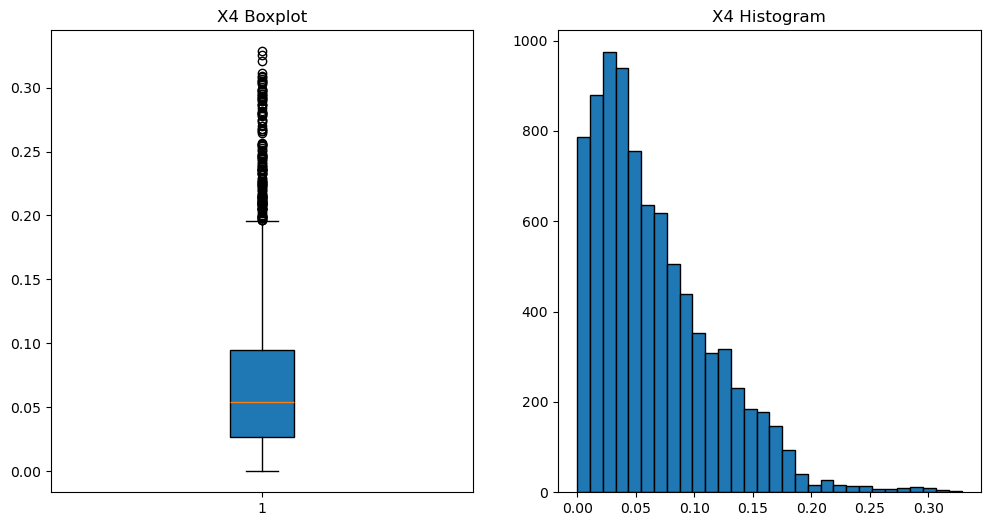

In [25]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.boxplot(df['X4'].dropna(), patch_artist= True)
plt.title('X4 Boxplot')
plt.subplot(1,2,2)
plt.hist(df['X4'], bins=30, edgecolor='black')
plt.title('X4 Histogram')
;

In [26]:
Q1 = df['X4'].quantile(0.25)
Q3 = df['X4'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['X4'] < lower_bound) | (df['X4'] > upper_bound)]
print(f"Number of outliers in X4: {outliers.shape[0]}")

Number of outliers in X4: 144


In [27]:
df['X4'] = df['X4'].clip(lower_bound, upper_bound)

print("Outliers handled using IQR method")

Outliers handled using IQR method


''

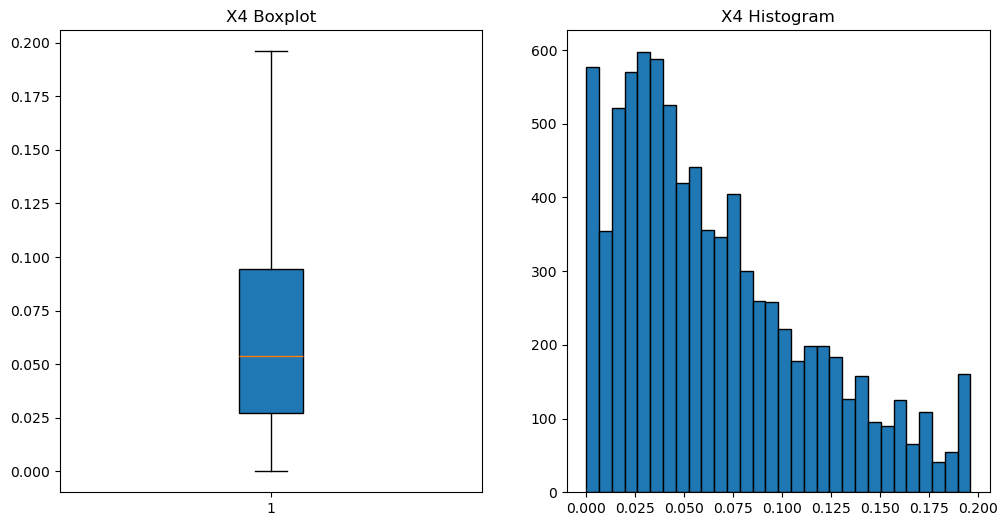

In [28]:
# Verify X4 distribution after outlier handling and transformation
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.boxplot(df['X4'], patch_artist= True)
plt.title('X4 Boxplot')
plt.subplot(1,2,2)
plt.hist(df['X4'], bins=30, edgecolor='black')
plt.title('X4 Histogram')
;

In [29]:
df.head(3)

,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,1,0
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,3,2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,1,0


In [30]:
# Display value counts for all categorical columns

categorical_cols = ['X3', 'X5', 'X7', 'X9']
for i in categorical_cols:
    print(f"Value counts for {i}:")
    print(df[i].value_counts())
    print("_"*25+"\n")

Value counts for X3:
X3
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64
_________________________

Value counts for X5:
X5
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64
_________________________

Value counts for X7:
X7
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64
_________________________

Value counts for X9:
X9
Medium    5203
Small     2388
High       932


In [31]:
df.head(3)

,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,1,0
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,3,2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,1,0


In [32]:
# Ordinal encoding for X9 (Outlet Size) - since it has a natural order (Small < Medium < High)
encoder = OrdinalEncoder(
    categories=[['Small', 'Medium', 'High']]
)

df[['X9']] = encoder.fit_transform(df[['X9']])

df['X9']

0       1.0
1       1.0
2       1.0
3       1.0
4       2.0
       ... 
8518    2.0
8519    1.0
8520    0.0
8521    1.0
8522    0.0
Name: X9, Length: 8523, dtype: float64

In [33]:
df.X3.value_counts()

X3
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [34]:
# Standardize category names in X3 for consistency
df['X3'] = df['X3'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

In [35]:
# Verify the changes
df.X3.value_counts()

X3
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [36]:
df.head(3)

,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,1.0,1,0
1,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,1.0,3,2
2,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,1.0,1,0


In [37]:
# Ordinal encoding for X3 (Fat Content) - since it has a natural order (Low Fat < Regular)
encoder = OrdinalEncoder(
    categories=[['Low Fat', 'Regular']]
)

df[['X3']] = encoder.fit_transform(df[['X3']])

df['X3']

0       0.0
1       1.0
2       0.0
3       1.0
4       0.0
       ... 
8518    0.0
8519    1.0
8520    0.0
8521    1.0
8522    0.0
Name: X3, Length: 8523, dtype: float64

In [38]:
df.head(3)

,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
0,9.30,0.0,0.016047,Dairy,249.8092,OUT049,1999,1.0,1,0
1,5.92,1.0,0.019278,Soft Drinks,48.2692,OUT018,2009,1.0,3,2
2,17.50,0.0,0.016760,Meat,141.6180,OUT049,1999,1.0,1,0


In [39]:
df.Y.value_counts()

Y
0    5577
1    1083
3     935
2     928
Name: count, dtype: int64

### distribution of X4

<Axes: >

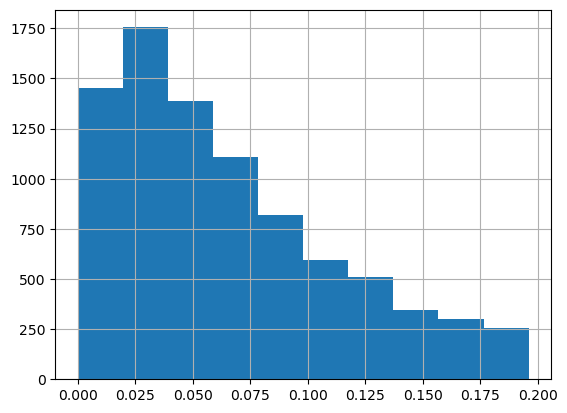

In [40]:

df.X4.hist()

In [41]:
# Check for zero values in X4
df[df.X4 == 0]

,X2,X3,X4,X5,X6,X7,X8,X9,X10,Y
3,19.200000,1.0,0.0,Fruits and Vegetables,182.0950,OUT010,1998,1.0,3,1
4,8.930000,0.0,0.0,Household,53.8614,OUT013,1987,2.0,3,0
5,10.395000,1.0,0.0,Baking Goods,51.4008,OUT018,2009,1.0,3,2
10,11.800000,0.0,0.0,Fruits and Vegetables,45.5402,OUT049,1999,1.0,1,0
32,18.700000,0.0,0.0,Snack Foods,256.6672,OUT018,2009,1.0,3,2
...,...,...,...,...,...,...,...,...,...,...
8480,12.857645,0.0,0.0,Snack Foods,154.5340,OUT019,1985,0.0,1,1
8484,6.865000,0.0,0.0,Soft Drinks,129.9652,OUT013,1987,2.0,3,0
8486,20.000000,1.0,0.0,Fruits and Vegetables,46.4744,OUT010,1998,1.0,3,1
8494,15.200000,0.0,0.0,Household,110.4912,OUT017,2007,1.0,2,0


replace with mean

In [42]:
df['X4'] = df['X4'].replace(0, np.mean(df['X4']))

In [43]:
# Apply log transformation to X4
logT = np.log1p(df['X4'])

logT.head()

logT.skew()

np.float64(0.8127862776829917)

In [44]:
pt_bc = PowerTransformer(method='box-cox')

df['X4_boxcox'] = pt_bc.fit_transform(df[['X4']])

df['X4_boxcox'].skew()

np.float64(-0.04714553054620693)

In [45]:
df.drop(columns=['X4'], inplace=True)
df.head(3)

,X2,X3,X5,X6,X7,X8,X9,X10,Y,X4_boxcox
0,9.30,0.0,Dairy,249.8092,OUT049,1999,1.0,1,0,-1.499735
1,5.92,1.0,Soft Drinks,48.2692,OUT018,2009,1.0,3,2,-1.320287
2,17.50,0.0,Meat,141.6180,OUT049,1999,1.0,1,0,-1.458087


''

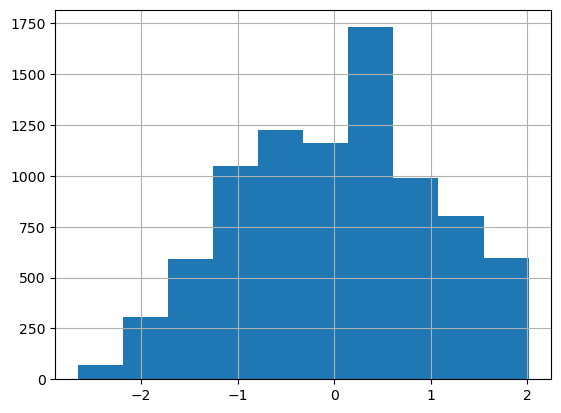

In [46]:
df.X4_boxcox.hist()
;
#distribution looks much better after Box-Cox transformation, with reduced skewness and fewer outliers.

Checking the value counts for columns X7 and X5 to see if one-hot encoding would cause dimensionality problems or not (in our case its ok)

In [47]:
df.X7.value_counts()

X7
OUT027    935
OUT013    932
OUT049    930
OUT046    930
OUT035    930
OUT045    929
OUT018    928
OUT017    926
OUT010    555
OUT019    528
Name: count, dtype: int64

In [48]:
df.X5.value_counts()

X5
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

In [49]:
df2 = pd.get_dummies(df, columns=['X5', 'X7'], drop_first=True,dtype=int)
df2.head(3)

,X2,X3,X6,X8,X9,X10,Y,X4_boxcox,X5_Breads,X5_Breakfast,X5_Canned,X5_Dairy,X5_Frozen Foods,X5_Fruits and Vegetables,X5_Hard Drinks,X5_Health and Hygiene,X5_Household,X5_Meat,X5_Others,X5_Seafood,X5_Snack Foods,X5_Soft Drinks,X5_Starchy Foods,X7_OUT013,X7_OUT017,X7_OUT018,X7_OUT019,X7_OUT027,X7_OUT035,X7_OUT045,X7_OUT046,X7_OUT049
0,9.30,0.0,249.8092,1999,1.0,1,0,-1.499735,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,5.92,1.0,48.2692,2009,1.0,3,2,-1.320287,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
2,17.50,0.0,141.6180,1999,1.0,1,0,-1.458087,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [50]:
df2.columns.shape

(32,)

In [51]:
# Reorder columns to have numeric features first, then one-hot encoded features, and finally the target variable Y at the end.
new_order = ['X2', 'X3', 'X4_boxcox', 'X6', 'X8', 'X9', 'X10',
             'X5_Breads','X5_Breakfast', 'X5_Canned', 'X5_Dairy', 'X5_Frozen Foods',
            'X5_Fruits and Vegetables', 'X5_Hard Drinks', 'X5_Health and Hygiene',
            'X5_Household', 'X5_Meat', 'X5_Others', 'X5_Seafood', 'X5_Snack Foods',
            'X5_Soft Drinks', 'X5_Starchy Foods', 'X7_OUT013', 'X7_OUT017',
            'X7_OUT018', 'X7_OUT019', 'X7_OUT027', 'X7_OUT035', 'X7_OUT045',
            'X7_OUT046', 'X7_OUT049', 'Y'] 
df2 = df2[new_order]

In [52]:
df2.head(3)

,X2,X3,X4_boxcox,X6,X8,X9,X10,X5_Breads,X5_Breakfast,X5_Canned,X5_Dairy,X5_Frozen Foods,X5_Fruits and Vegetables,X5_Hard Drinks,X5_Health and Hygiene,X5_Household,X5_Meat,X5_Others,X5_Seafood,X5_Snack Foods,X5_Soft Drinks,X5_Starchy Foods,X7_OUT013,X7_OUT017,X7_OUT018,X7_OUT019,X7_OUT027,X7_OUT035,X7_OUT045,X7_OUT046,X7_OUT049,Y
0,9.30,0.0,-1.499735,249.8092,1999,1.0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,5.92,1.0,-1.320287,48.2692,2009,1.0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,2
2,17.50,0.0,-1.458087,141.6180,1999,1.0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [53]:
# Create a heatmap of the correlation matrix
heatmap_data = df2[['X2','X3', 'X4_boxcox', 'X6']]

In [54]:
# max correlation value (excluding the diagonal of 1s)
heatmap_data.corr()[heatmap_data.corr() != 1].max().max()

0.0559058888235602

                 X2        X3  X4_boxcox        X6
X2         1.000000 -0.021157  -0.018402  0.024756
X3        -0.021157  1.000000   0.055906  0.006063
X4_boxcox -0.018402  0.055906   1.000000 -0.001851
X6         0.024756  0.006063  -0.001851  1.000000


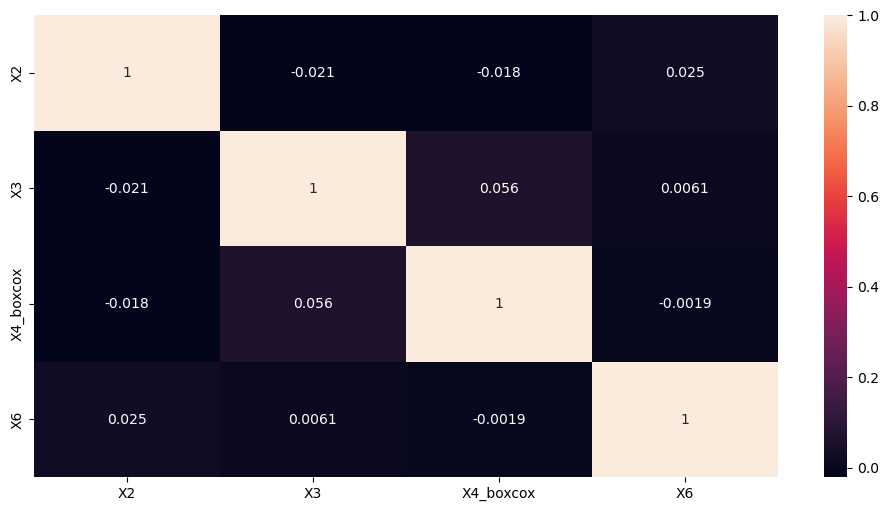

In [55]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data.corr(), annot=True)
print(heatmap_data.corr())
plt.show();


In [56]:
# Check for multicollinearity by looking at the correlation matrix
df2.corr()[df2.corr() != 1].max().sort_values(ascending=False)

Y                           0.780031
X7_OUT027                   0.780031
X9                          0.683424
X7_OUT013                   0.683424
X10                         0.614311
X8                          0.466336
X7_OUT018                   0.466336
X7_OUT017                   0.382361
X7_OUT035                   0.257868
X7_OUT045                   0.174150
X4_boxcox                   0.164275
X7_OUT019                   0.164275
X3                          0.118574
X5_Meat                     0.118574
X5_Fruits and Vegetables    0.116955
X7_OUT049                   0.099596
X5_Frozen Foods             0.085041
X5_Canned                   0.073235
X5_Breakfast                0.065711
X5_Snack Foods              0.059848
X5_Household                0.046815
X6                          0.046815
X5_Dairy                    0.037357
X2                          0.035968
X5_Breads                   0.032643
X5_Others                   0.027165
X5_Starchy Foods            0.025945
X

In [57]:
#looking for correlation between X9, X10, and X8
heatmap_data = df2[['X9', "X10",'X8']]

           X9       X10        X8
X9   1.000000  0.614311 -0.193389
X10  0.614311  1.000000 -0.089216
X8  -0.193389 -0.089216  1.000000


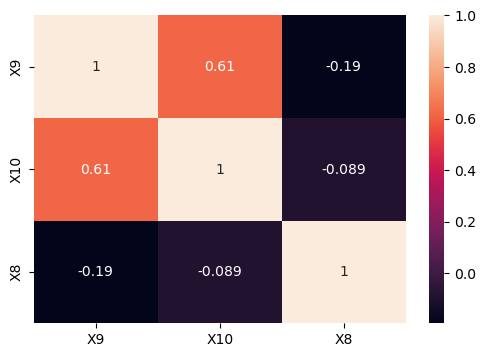

In [58]:
plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data.corr(), annot=True)
print(heatmap_data.corr())
plt.show();

In [59]:
df2.head(3)

,X2,X3,X4_boxcox,X6,X8,X9,X10,X5_Breads,X5_Breakfast,X5_Canned,X5_Dairy,X5_Frozen Foods,X5_Fruits and Vegetables,X5_Hard Drinks,X5_Health and Hygiene,X5_Household,X5_Meat,X5_Others,X5_Seafood,X5_Snack Foods,X5_Soft Drinks,X5_Starchy Foods,X7_OUT013,X7_OUT017,X7_OUT018,X7_OUT019,X7_OUT027,X7_OUT035,X7_OUT045,X7_OUT046,X7_OUT049,Y
0,9.30,0.0,-1.499735,249.8092,1999,1.0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,5.92,1.0,-1.320287,48.2692,2009,1.0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,2
2,17.50,0.0,-1.458087,141.6180,1999,1.0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


#### Doing the same EDA for the testing dataset:

In [60]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      5681 non-null   object 
 1   X2      4705 non-null   float64
 2   X3      5681 non-null   object 
 3   X4      5681 non-null   float64
 4   X5      5681 non-null   object 
 5   X6      5681 non-null   float64
 6   X7      5681 non-null   object 
 7   X8      5681 non-null   int64  
 8   X9      4075 non-null   object 
 9   X10     5681 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 444.0+ KB


In [61]:
df_test.describe()

,X2,X4,X6,X8
count,4705.000000,5681.000000,5681.000000,5681.000000
mean,12.695633,0.065684,141.023273,1997.828903
std,4.664849,0.051252,61.809091,8.372256
min,4.555000,0.000000,31.990000,1985.000000
25%,8.645000,0.027047,94.412000,1987.000000
50%,12.500000,0.054154,141.415400,1999.000000
75%,16.700000,0.093463,186.026600,2004.000000
max,21.350000,0.323637,266.588400,2009.000000


In [62]:
df_test.drop(columns=['X1'], inplace=True)
df_test.head(3)

,X2,X3,X4,X5,X6,X7,X8,X9,X10
0,20.75,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1
1,8.30,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2
2,14.60,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3


In [63]:
df.drop_duplicates(inplace=True)

In [64]:
# show amount of missing values
print("Missing values before handling:")
df_test.isnull().sum()

Missing values before handling:


X2      976
X3        0
X4        0
X5        0
X6        0
X7        0
X8        0
X9     1606
X10       0
dtype: int64

In [65]:
# Fill missing values in X2 and X9
df_test['X2'].fillna(df_test['X2'].mean(), inplace=True)
df_test['X9'].fillna(df_test['X9'].mode()[0], inplace=True)


In [66]:
print("Missing values after handling:")
df_test.isnull().sum()

Missing values after handling:


X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
dtype: int64

In [67]:
df_test['X10'] = df_test['X10'].str[-1:]
df_test['X10'] = df_test['X10'].astype('int64')

In [68]:
numerical_df_test = df_test.select_dtypes(include = "number")
numerical_df_test.head(3)

,X2,X4,X6,X8,X10
0,20.75,0.007565,107.8622,1999,1
1,8.30,0.038428,87.3198,2007,2
2,14.60,0.099575,241.7538,1998,3


''

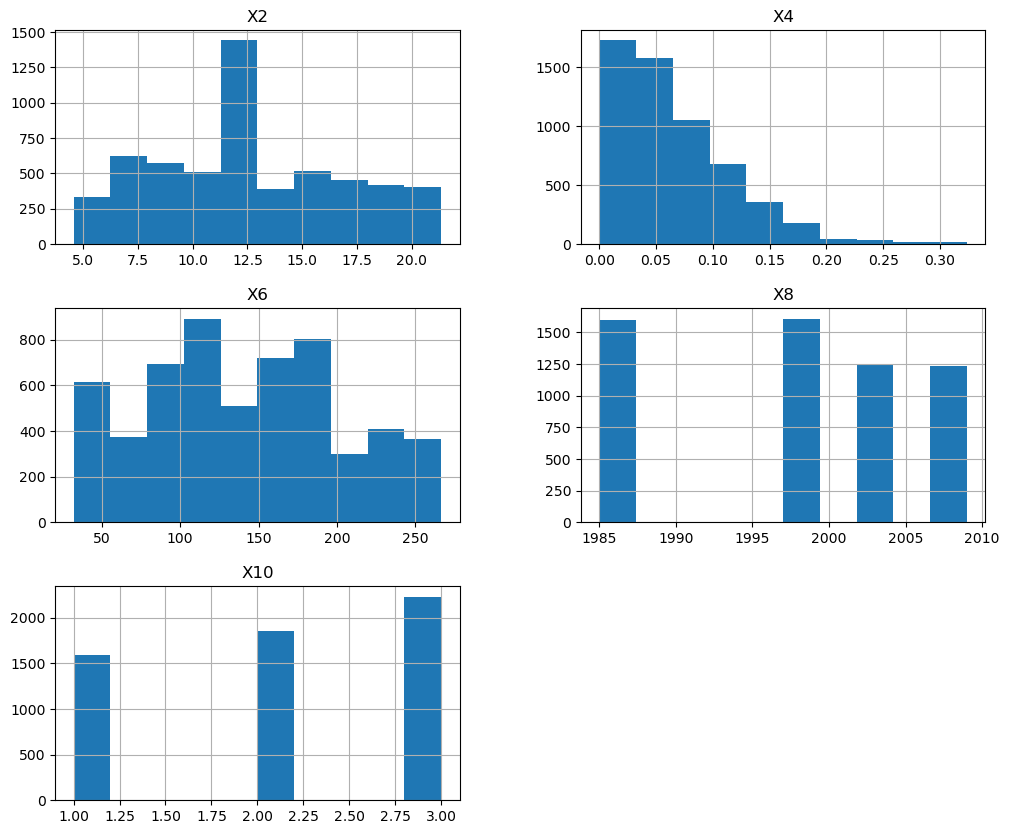

In [69]:
numerical_df_test.hist(figsize=(12, 10))
;

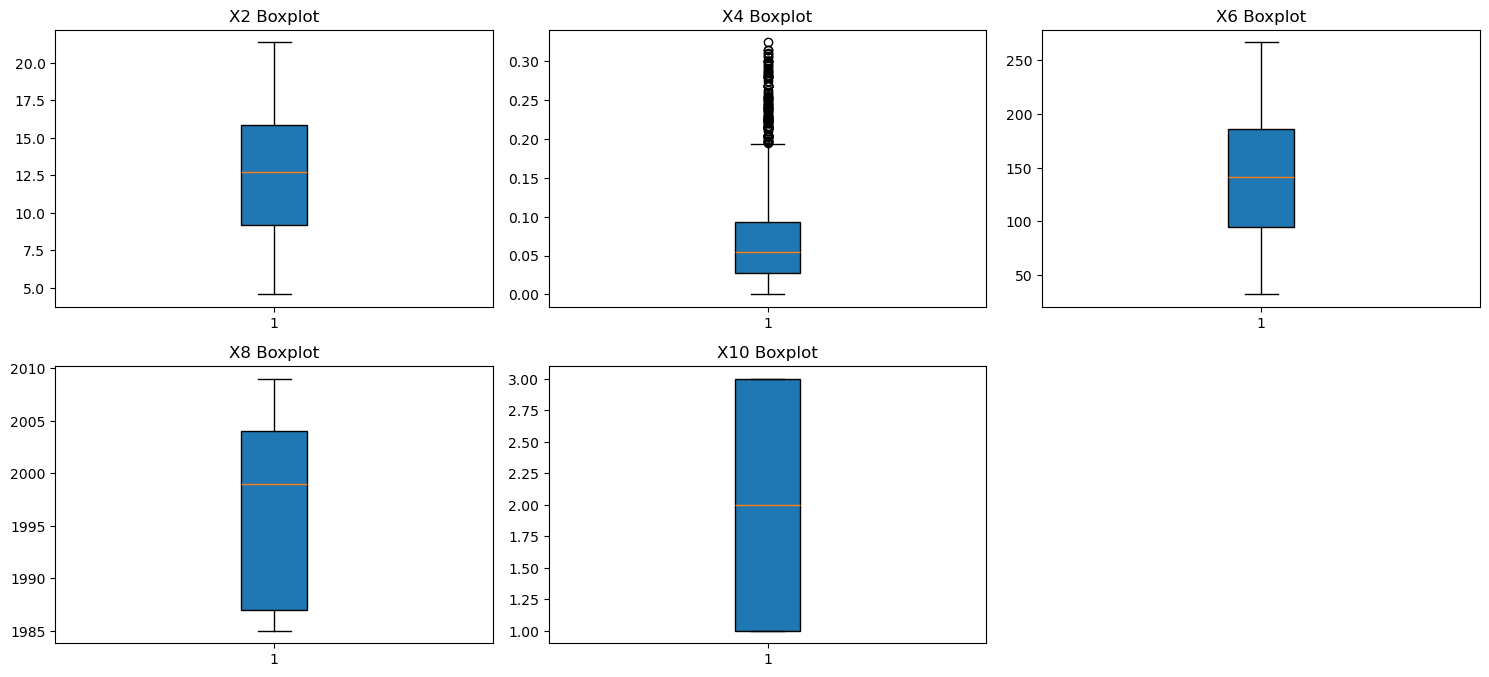

In [70]:
plt.figure(figsize=(15,10))
t=0
for i in (numerical_df_test.columns.tolist()):
    plt.subplot(3,3,t+1)
    plt.boxplot(numerical_df_test[i].dropna(), patch_artist= True)
    plt.title(f'{i} Boxplot')
    t+=1
    
plt.tight_layout()
plt.show()

In [71]:
Q1 = df_test['X4'].quantile(0.25)
Q3 = df_test['X4'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_test[(df_test['X4'] < lower_bound) | (df_test['X4'] > upper_bound)]
print(f"Number of outliers in X4: {outliers.shape[0]}")
df_test['X4'] = df_test['X4'].clip(lower_bound, upper_bound)

print("Outliers handled using IQR method")

Number of outliers in X4: 113
Outliers handled using IQR method


''

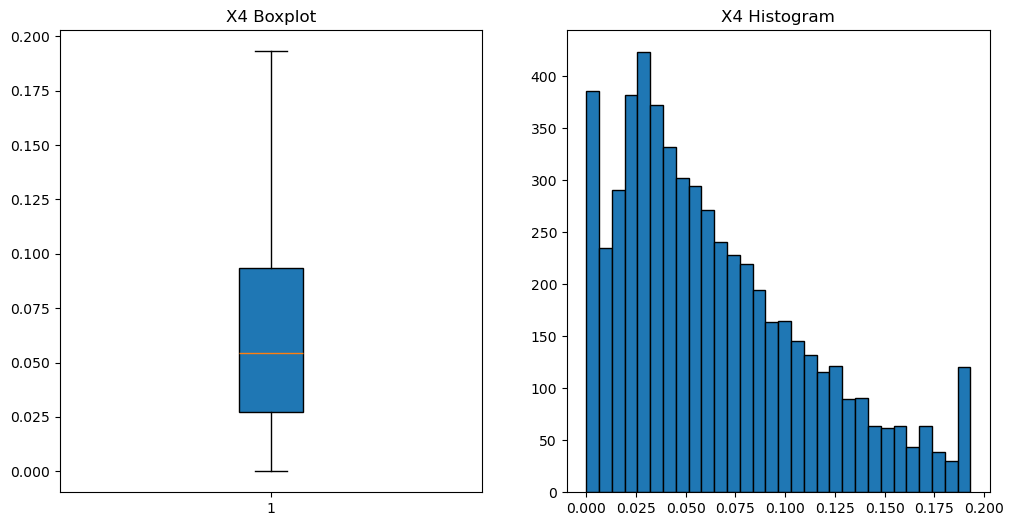

In [72]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.boxplot(df_test['X4'], patch_artist= True)
plt.title('X4 Boxplot')
plt.subplot(1,2,2)
plt.hist(df_test['X4'], bins=30, edgecolor='black')
plt.title('X4 Histogram')
;

''

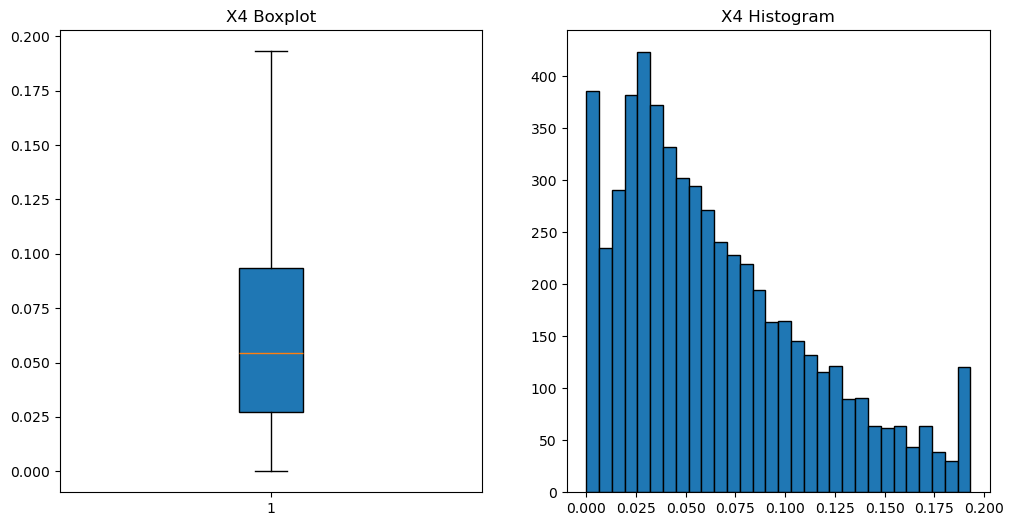

In [73]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.boxplot(df_test['X4'], patch_artist= True)
plt.title('X4 Boxplot')
plt.subplot(1,2,2)
plt.hist(df_test['X4'], bins=30, edgecolor='black')
plt.title('X4 Histogram')
;

In [74]:
encoder = OrdinalEncoder(
    categories=[['Small', 'Medium', 'High']]
)

df_test[['X9']] = encoder.fit_transform(df_test[['X9']])

df_test['X9']

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
5676    0.0
5677    1.0
5678    1.0
5679    1.0
5680    1.0
Name: X9, Length: 5681, dtype: float64

In [75]:
df_test.X3.value_counts()

X3
Low Fat    3396
Regular    1935
LF          206
reg          78
low fat      66
Name: count, dtype: int64

In [76]:
df_test['X3'] = df_test['X3'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})
df_test.X3.value_counts()

X3
Low Fat    3668
Regular    2013
Name: count, dtype: int64

In [77]:
encoder = OrdinalEncoder(
    categories=[['Low Fat', 'Regular']]
)

df_test[['X3']] = encoder.fit_transform(df_test[['X3']])

df_test['X3']

0       0.0
1       1.0
2       0.0
3       0.0
4       1.0
       ... 
5676    1.0
5677    1.0
5678    0.0
5679    1.0
5680    1.0
Name: X3, Length: 5681, dtype: float64

In [78]:
df_test['X4'] = df_test['X4'].replace(0, np.mean(df_test['X4']))

In [79]:
# Apply log transformation to X4
logT = np.log1p(df_test['X4'])

logT.head()

logT.skew()

np.float64(0.8238560525265681)

In [80]:
pt_bc = PowerTransformer(method='box-cox')

df_test['X4_boxcox'] = pt_bc.fit_transform(df_test[['X4']])

df_test['X4_boxcox'].skew()

np.float64(-0.045153916276641504)

In [81]:
df_test.drop(columns=['X4'], inplace=True)
df_test.head(3)

,X2,X3,X5,X6,X7,X8,X9,X10,X4_boxcox
0,20.75,0.0,Snack Foods,107.8622,OUT049,1999,1.0,1,-2.154057
1,8.30,1.0,Dairy,87.3198,OUT017,2007,1.0,2,-0.556012
2,14.60,0.0,Others,241.7538,OUT010,1998,1.0,3,0.815489


In [82]:
df2_test = pd.get_dummies(df_test, columns=['X5', 'X7'], drop_first=True,dtype=int)
df2_test.head(1)

,X2,X3,X6,X8,X9,X10,X4_boxcox,X5_Breads,X5_Breakfast,X5_Canned,X5_Dairy,X5_Frozen Foods,X5_Fruits and Vegetables,X5_Hard Drinks,X5_Health and Hygiene,X5_Household,X5_Meat,X5_Others,X5_Seafood,X5_Snack Foods,X5_Soft Drinks,X5_Starchy Foods,X7_OUT013,X7_OUT017,X7_OUT018,X7_OUT019,X7_OUT027,X7_OUT035,X7_OUT045,X7_OUT046,X7_OUT049
0,20.75,0.0,107.8622,1999,1.0,1,-2.154057,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1


In [83]:
df2_test.columns

Index(['X2', 'X3', 'X6', 'X8', 'X9', 'X10', 'X4_boxcox', 'X5_Breads',
       'X5_Breakfast', 'X5_Canned', 'X5_Dairy', 'X5_Frozen Foods',
       'X5_Fruits and Vegetables', 'X5_Hard Drinks', 'X5_Health and Hygiene',
       'X5_Household', 'X5_Meat', 'X5_Others', 'X5_Seafood', 'X5_Snack Foods',
       'X5_Soft Drinks', 'X5_Starchy Foods', 'X7_OUT013', 'X7_OUT017',
       'X7_OUT018', 'X7_OUT019', 'X7_OUT027', 'X7_OUT035', 'X7_OUT045',
       'X7_OUT046', 'X7_OUT049'],
      dtype='object')

In [84]:
new_order = ['X2', 'X3', 'X4_boxcox', 'X6', 'X8', 'X9', 'X10',
             'X5_Breads','X5_Breakfast', 'X5_Canned', 'X5_Dairy', 'X5_Frozen Foods',
            'X5_Fruits and Vegetables', 'X5_Hard Drinks', 'X5_Health and Hygiene',
            'X5_Household', 'X5_Meat', 'X5_Others', 'X5_Seafood', 'X5_Snack Foods',
            'X5_Soft Drinks', 'X5_Starchy Foods', 'X7_OUT013', 'X7_OUT017',
            'X7_OUT018', 'X7_OUT019', 'X7_OUT027', 'X7_OUT035', 'X7_OUT045',
            'X7_OUT046', 'X7_OUT049'] 
df2_test = df2_test[new_order]

In [85]:
df2_test.corr()[df2_test.corr() != 1].max().sort_values(ascending=False)

X9                          0.683357
X7_OUT013                   0.683357
X10                         0.614284
X8                          0.466210
X7_OUT018                   0.466210
X7_OUT027                   0.383437
X7_OUT017                   0.382395
X7_OUT035                   0.258010
X7_OUT045                   0.174233
X4_boxcox                   0.165375
X7_OUT019                   0.165375
X3                          0.143660
X5_Meat                     0.143660
X5_Frozen Foods             0.106598
X5_Canned                   0.100840
X7_OUT049                   0.099660
X5_Breakfast                0.077103
X5_Snack Foods              0.064303
X5_Breads                   0.053765
X5_Fruits and Vegetables    0.051578
X2                          0.045257
X6                          0.045257
X5_Household                0.039714
X5_Others                   0.035828
X5_Dairy                    0.032749
X5_Starchy Foods            0.026422
X5_Health and Hygiene       0.025588
X

In [86]:
#changing X10 to int64 for both train and test datasets to avoid any issues during modeling since it is a numeric feature.

df['X10'] = df['X10'].astype('int64')
df2['X10'] = df2['X10'].astype('int64')

## ______________________________________________________________________________________________________

In [87]:
x7_cols = [col for col in df2.columns if 'X7_' in col]

X = df2.drop(columns=['Y', 'X8'] + x7_cols)
y = df2['Y']

In [88]:
# Stratified split to maintain class distribution in both training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [89]:
# Modeling with Gaussian Naive Bayes

nb_classifier = GaussianNB()
nb_classifier.fit(X_val, y_val)

# Make predictions
y_pred = nb_classifier.predict(X_val)




# Evaluate the model

acc = accuracy_score(y_val, y_pred)

f1 = f1_score(
    y_val,
    y_pred,
    average='macro'
)

print("Accuracy:", f"{acc:.2f}")
print("Macro F1 Score:", f"{f1:.2f}")

Accuracy: 0.83
Macro F1 Score: 0.71


In [90]:
# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print(cm)

[[1022   94    0    0]
 [  67   44  106    0]
 [   0    2  183    0]
 [   0    0   20  167]]


In [91]:
# Classification Report of precision, recall, and F1-score for each class
print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.92      0.93      1116
           1       0.31      0.20      0.25       217
           2       0.59      0.99      0.74       185
           3       1.00      0.89      0.94       187

    accuracy                           0.83      1705
   macro avg       0.71      0.75      0.71      1705
weighted avg       0.83      0.83      0.82      1705



In [92]:
# Modeling with Random Forest Classifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)




acc = accuracy_score(y_val, y_pred)

f1 = f1_score(
    y_val,
    y_pred,
    average='macro'
)

print("Accuracy:", f"{acc:.2f}")
print("Macro F1 Score:", f"{f1:.2f}")


Accuracy: 0.93
Macro F1 Score: 0.85


Random Forrest Classifier got bot higher accuracy and f1 score

In [93]:
print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1116
           1       0.78      0.64      0.70       217
           2       0.65      0.78      0.71       185
           3       1.00      1.00      1.00       187

    accuracy                           0.93      1705
   macro avg       0.86      0.85      0.85      1705
weighted avg       0.93      0.93      0.93      1705



In [94]:
cm = confusion_matrix(y_val, y_pred)

print(cm)

[[1116    0    0    0]
 [   0  138   79    0]
 [   0   40  145    0]
 [   0    0    0  187]]


In [95]:
# Reprepare data for modeling ... but here we will keep X7 and X10
X = df2.drop(columns=['Y','X8'])
y = df2['Y']


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [96]:
model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    verbose=100
)

In [97]:
model.fit(X_train, y_train)

0:	learn: 1.1077054	total: 148ms	remaining: 1m 14s
100:	learn: 0.0007684	total: 559ms	remaining: 2.21s
200:	learn: 0.0002425	total: 996ms	remaining: 1.48s
300:	learn: 0.0001477	total: 1.5s	remaining: 991ms
400:	learn: 0.0001070	total: 1.93s	remaining: 476ms
499:	learn: 0.0000843	total: 2.38s	remaining: 0us


CatBoostClassifier(depth=6, iterations=500, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

In [98]:
y_pred = model.predict(X_val)

In [99]:
y_pred = y_pred.flatten()

In [100]:

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average='macro'))

print(classification_report(y_val, y_pred))

Accuracy: 1.0
Macro F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1116
           1       1.00      1.00      1.00       217
           2       1.00      1.00      1.00       185
           3       1.00      1.00      1.00       187

    accuracy                           1.00      1705
   macro avg       1.00      1.00      1.00      1705
weighted avg       1.00      1.00      1.00      1705



#### Getting accuracy of 1 indicates perfect predictions on the validation set, which may suggest overfitting.
#### We should be cautious and consider further validation techniques such as cross-validation to confirm the model's performance.

In [101]:

model = CatBoostClassifier(
    loss_function='MultiClass',
    eval_metric='TotalF1',   # good for imbalanced multiclass
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=3,
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100
)

In [102]:
#trying again but this time we will drop X7
X = df2.drop(columns=['Y','X8']+x7_cols)
y = df2['Y']


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    use_best_model=True
)



0:	learn: 0.9023560	test: 0.9044273	best: 0.9044273 (0)	total: 5.35ms	remaining: 10.7s
200:	learn: 0.9464042	test: 0.9438442	best: 0.9444801 (192)	total: 934ms	remaining: 8.36s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.9458824233
bestIteration = 291

Shrink model to first 292 iterations.


CatBoostClassifier(depth=6, early_stopping_rounds=100, eval_metric='TotalF1', iterations=2000, l2_leaf_reg=3, learning_rate=0.03, loss_function='MultiClass', random_seed=42, verbose=200)

In [103]:
y_pred = model.predict(X_val).flatten()



print("Accuracy:", f"{accuracy_score(y_val, y_pred):.2f}")
print("Macro F1:", f"{f1_score(y_val, y_pred, average='macro'):.2f}")

Accuracy: 0.95
Macro F1: 0.89


In [104]:
depth = [4, 6, 8, 10]
learning_rate = [0.01, 0.03, 0.05, 0.1]
l2_leaf_reg = [1, 3, 5, 10]
iterations = 3000
early_stopping_rounds = 100

best_score = 0
best_params = None

for depth in [4, 6, 8]:
    for lr in [0.01, 0.03, 0.05]:
        model = CatBoostClassifier(
            loss_function='MultiClass',
            iterations=3000,
            depth=depth,
            learning_rate=lr,
            l2_leaf_reg=3,
            random_seed=42,
            verbose=0,
            early_stopping_rounds=100
        )

        model.fit(X_train, y_train, eval_set=(X_val, y_val), use_best_model=True)

        preds = model.predict(X_val).flatten()
        score = f1_score(y_val, preds, average='macro')

        if score > best_score:
            best_score = score
            best_params = (depth, lr)

print("Best Macro F1:", best_score)
print("Best params (depth, lr):", best_params)

Best Macro F1: 0.8859821068181345
Best params (depth, lr): (6, 0.05)


Accuracy isnt 1.... which suggests that there must be a way to perfectly predict Y using X7 (thats why we got 1 earlier)

In [105]:
X = df.drop(columns=['Y','X8'])
y = df['Y']


X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=999,
    stratify=y
)





In [106]:
cat_features = ['X5', 'X7']
X_train['X5'] = X_train['X5'].astype(str)
X_train['X7'] = X_train['X7'].astype(str)

X_val['X5'] = X_val['X5'].astype(str)
X_val['X7'] = X_val['X7'].astype(str)

In [107]:
model = CatBoostClassifier(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    eval_metric='TotalF1',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=200
)

model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    use_best_model=True
)

0:	learn: 0.9975042	test: 1.0000000	best: 1.0000000 (0)	total: 50.9ms	remaining: 2m 32s
200:	learn: 0.9998533	test: 1.0000000	best: 1.0000000 (0)	total: 9.75s	remaining: 2m 15s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.


CatBoostClassifier(depth=6, early_stopping_rounds=200, eval_metric='TotalF1', iterations=3000, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=200)

In [108]:
y_pred = model.predict(X_val).flatten()

print("Accuracy:", accuracy_score(y_val, y_pred))
print("Macro F1:", f1_score(y_val, y_pred, average='macro'))

Accuracy: 1.0
Macro F1: 1.0


After verifying:
Market type Y can be predicted perfectly while knowing X7 outlet ID

In [109]:
# train and validation sizes
print("Train size:", len(X_train))
print("Val size:", len(X_val))

Train size: 6818
Val size: 1705


In [110]:
# Check for overlapping rows between training and validation sets using hashing
train_hash = pd.util.hash_pandas_object(X_train).isin(
    pd.util.hash_pandas_object(X_val)
).sum()

print("Overlapping rows:", train_hash)

Overlapping rows: 0


In [111]:
# Baseline model using DummyClassifier to predict the most frequent class
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

print(dummy.score(X_val, y_val))

0.6545454545454545


In [112]:
# Display the shapes and first few rows of the training and validation sets to verify they are correct
print(X_train.shape, X_val.shape)

(6818, 8) (1705, 8)


In [113]:
X_train.head(3)

,X2,X3,X5,X6,X7,X9,X10,X4_boxcox
7380,12.857645,0.0,Household,123.3414,OUT027,1.0,3,-1.722621
3045,11.600000,1.0,Frozen Foods,169.3106,OUT045,1.0,2,0.401334
255,12.857645,0.0,Frozen Foods,41.5796,OUT019,0.0,1,1.484495


In [114]:
X_val.head(3)

,X2,X3,X5,X6,X7,X9,X10,X4_boxcox
5625,9.06,0.0,Others,211.8560,OUT018,1.0,3,-1.935704
2535,8.05,1.0,Fruits and Vegetables,257.0646,OUT017,1.0,2,0.430833
5969,10.50,0.0,Soft Drinks,185.6240,OUT013,2.0,3,-1.333081


In [115]:
print("Train accuracy check:",
      accuracy_score(y_train, model.predict(X_train)))

print("Val accuracy check:",
      accuracy_score(y_val, model.predict(X_val)))

Train accuracy check: 1.0
Val accuracy check: 1.0


In [116]:
# Cross-validation with CatBoost using StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))   # out-of-fold predictions
test_preds = []
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):

    print(f"\nFold {fold+1}")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations=3000,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_seed=42,
        verbose=200,
        early_stopping_rounds=200
    )

    model.fit(
        X_train, y_train,
        cat_features=['X5', 'X7'],
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    preds = model.predict(X_val).flatten()
    oof_preds[val_idx] = preds





Fold 1
0:	learn: 0.9975042	test: 1.0000000	best: 1.0000000 (0)	total: 37.9ms	remaining: 1m 53s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 9.68s	remaining: 2m 14s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.

Fold 2
0:	learn: 0.9975042	test: 1.0000000	best: 1.0000000 (0)	total: 34.2ms	remaining: 1m 42s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 8.68s	remaining: 2m
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.

Fold 3
0:	learn: 0.9975042	test: 1.0000000	best: 1.0000000 (0)	total: 31.7ms	remaining: 1m 35s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 8.9s	remaining: 2m 3s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.

Fold 4
0:	learn: 0.9998534	test: 1.0000000	best: 1.0000000 (0)	total: 40.2ms	r

In [117]:

print("CV Accuracy:", accuracy_score(y, oof_preds))
print("CV Macro F1:", f1_score(y, oof_preds, average='macro'))

CV Accuracy: 1.0
CV Macro F1: 1.0


In [118]:
# Prepare the whole training data for the final modeling
X = df.drop(columns=['Y'])
y = df['Y']

# ensure categorical columns are strings
X['X5'] = X['X5'].astype(str)
X['X7'] = X['X7'].astype(str)

In [119]:
# Cross-validation with CatBoost using StratifiedKFold

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_preds = np.zeros(len(X))

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):

    print(f"\n===== Fold {fold+1} =====")

    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        class_weights=[1.0,1.5,1.5,1.5],  # adjust based on class imbalance
        iterations=3000,
        learning_rate=0.05,
        depth=6,
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_seed=42,
        verbose=200,
        early_stopping_rounds=200
    )

    model.fit(
        X_train, y_train,
        cat_features=['X5', 'X7'],
        eval_set=(X_val, y_val),
        use_best_model=True
    )

    preds = model.predict(X_val).flatten()
    oof_preds[val_idx] = preds





===== Fold 1 =====
0:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 48.2ms	remaining: 2m 24s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 10.6s	remaining: 2m 27s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.

===== Fold 2 =====
0:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 47.9ms	remaining: 2m 23s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 9.82s	remaining: 2m 16s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.

===== Fold 3 =====
0:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 44.5ms	remaining: 2m 13s
200:	learn: 1.0000000	test: 1.0000000	best: 1.0000000 (0)	total: 10.2s	remaining: 2m 22s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 1
bestIteration = 0

Shrink model to first 1 iterations.

===== Fold 4 =====
0:	learn: 1.00000

In [120]:
cv_acc = accuracy_score(y, oof_preds)
cv_f1 = f1_score(y, oof_preds, average='macro')

print("\n===== FINAL CV SCORE =====")
print("CV Accuracy:", cv_acc)
print("CV Macro F1:", cv_f1)


===== FINAL CV SCORE =====
CV Accuracy: 1.0
CV Macro F1: 1.0


Understanding whether Outlet ID strongly determines the market type.

In [121]:
pd.crosstab(df['X7'], df['Y'])

Y,0,1,2,3
X7,,,,
OUT010,0,555,0,0
OUT013,932,0,0,0
OUT017,926,0,0,0
OUT018,0,0,928,0
OUT019,0,528,0,0
OUT027,0,0,0,935
OUT035,930,0,0,0
OUT045,929,0,0,0
OUT046,930,0,0,0


In [122]:
pd.crosstab([df['X7'], df['X10']], df['Y'])

,Y,0,1,2,3
X7,X10,,,,
OUT010,3,0,555,0,0
OUT013,3,932,0,0,0
OUT017,2,926,0,0,0
OUT018,3,0,0,928,0
OUT019,1,0,528,0,0
OUT027,3,0,0,0,935
OUT035,2,930,0,0,0
OUT045,2,929,0,0,0
OUT046,1,930,0,0,0


# _____________________________________________________________________________________

In [123]:
df.head(3)

,X2,X3,X5,X6,X7,X8,X9,X10,Y,X4_boxcox
0,9.30,0.0,Dairy,249.8092,OUT049,1999,1.0,1,0,-1.499735
1,5.92,1.0,Soft Drinks,48.2692,OUT018,2009,1.0,3,2,-1.320287
2,17.50,0.0,Meat,141.6180,OUT049,1999,1.0,1,0,-1.458087


In [124]:
df_test.head(2)

,X2,X3,X5,X6,X7,X8,X9,X10,X4_boxcox
0,20.75,0.0,Snack Foods,107.8622,OUT049,1999,1.0,1,-2.154057
1,8.30,1.0,Dairy,87.3198,OUT017,2007,1.0,2,-0.556012


##  Final Model Training & Submission

Train on the **full training set** (no held-out split) using the best configuration found during cross-validation, then generate predictions for the test set.

In [125]:
X = df.drop(columns=['Y'])
y = df['Y']

test_X = df_test.copy()

In [126]:
cat_cols = ['X5', 'X7']  

for col in cat_cols:
    X[col] = X[col].astype(str)
    test_X[col] = test_X[col].astype(str)

In [127]:

final_model = CatBoostClassifier(
    class_weights=[1.0,1.5,1.5,1.5],
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    loss_function='MultiClass',
    random_seed=42,
    verbose=200
)

final_model.fit(
    X,
    y,
    cat_features=cat_cols
)

0:	learn: 1.2419450	total: 43.7ms	remaining: 2m 11s
200:	learn: 0.0011032	total: 9.76s	remaining: 2m 15s
400:	learn: 0.0003894	total: 19.1s	remaining: 2m 3s
600:	learn: 0.0002388	total: 28.2s	remaining: 1m 52s
800:	learn: 0.0001690	total: 37.4s	remaining: 1m 42s
1000:	learn: 0.0001282	total: 46.6s	remaining: 1m 33s
1200:	learn: 0.0001038	total: 55.8s	remaining: 1m 23s
1400:	learn: 0.0000879	total: 1m 5s	remaining: 1m 14s
1600:	learn: 0.0000760	total: 1m 14s	remaining: 1m 5s
1800:	learn: 0.0000668	total: 1m 24s	remaining: 56.1s
2000:	learn: 0.0000594	total: 1m 33s	remaining: 46.7s
2200:	learn: 0.0000536	total: 1m 42s	remaining: 37.3s
2400:	learn: 0.0000490	total: 1m 52s	remaining: 27.9s
2600:	learn: 0.0000449	total: 2m 1s	remaining: 18.6s
2800:	learn: 0.0000416	total: 2m 10s	remaining: 9.28s
2999:	learn: 0.0000388	total: 2m 20s	remaining: 0us


CatBoostClassifier(class_weights=[1.0, 1.5, 1.5, 1.5], depth=6, iterations=3000, learning_rate=0.05, loss_function='MultiClass', random_seed=42, verbose=200)

In [128]:
test_preds = final_model.predict_proba(test_X).argmax(axis=1)
test_preds = test_preds.flatten()

In [129]:
# Build and save the submission CSV in the required format
submission = pd.DataFrame({
    'row_id': range(len(test_X)),
    'label': test_preds.astype(int)
})

submission.to_csv('submission.csv', index=False)

In [130]:
submission.head()


,row_id,label
0,0,0
1,1,0
2,2,1
3,3,0
4,4,3


In [131]:
submission['label'].value_counts()

label
0    3717
1     722
3     624
2     618
Name: count, dtype: int64